# Klausuraufgabe: Ausfälle von Windkraftanlagen vorhersagen mittels Logistischer Regression

### Kontext & Datensatzbeschreibung
Im Rahmen der Zustandsüberwachung (Condition Monitoring) einer Windkraftanlage wurden Sensordaten von insgesamt $n = 1000$ Betriebsdatenpunkten erfasst. Das Ziel ist es, drohende Getriebeschäden frühzeitig zu erkennen, bevor ein katastrophaler Ausfall eintritt. 

Der Datensatz `wind_turbine_data.csv` enthält folgende Merkmale (Features):
* **`vibration_mm_s` ($x_1$):** Die Vibrationsamplitude des Getriebes in mm/s.
* **`temperature_celsius` ($x_2$):** Die Getriebeöltemperatur in °C.
* **`target_y` ($y$):** Der reale Zustand der Anlage ($y = 0 \rightarrow$ Normalbetrieb, $y = 1 \rightarrow$ Ausfall/Defekt).

**Die Herausforderung (Unbalanced Data):**
Wie im Maschinenbau üblich, treten Defekte extrem selten auf. Der Datensatz ist stark unbalanciert: **95 %** der Daten repräsentieren den Normalbetrieb ($n_0 = 950$), nur **5 %** zeigen einen Defekt ($n_1 = 50$). Eine Standard-Logistische-Regression würde hier die Minderheitenklasse vernachlässigen, da das Modell auch dann eine Genauigkeit (Accuracy) von 95 % erreicht, wenn es einfach *nie* einen Ausfall vorhersagt.

---

### Aufgabenstellung

Bearbeiten Sie die folgenden Teilaufgaben in den entsprechenden Code- und Textzellen.

---

In [1]:
# Vorbereitung: Benötigte Bibliotheken importieren

import numpy as np
import pandas as pd                 
from sklearn.metrics import log_loss, f1_score, confusion_matrix    

In [2]:
# =====================================================================
# DATEN LADEN
# =====================================================================
df = pd.read_csv('wind_turbine_data.csv')
X_raw = df[['vibration_mm_s', 'temperature_celsius']].values
y = df['target_y'].values
df.head()

,vibration_mm_s,temperature_celsius,target_y
0,1.82,56.22,0
1,1.12,63.69,0
2,2.20,60.27,0
3,0.97,54.10,0
4,2.01,65.65,0


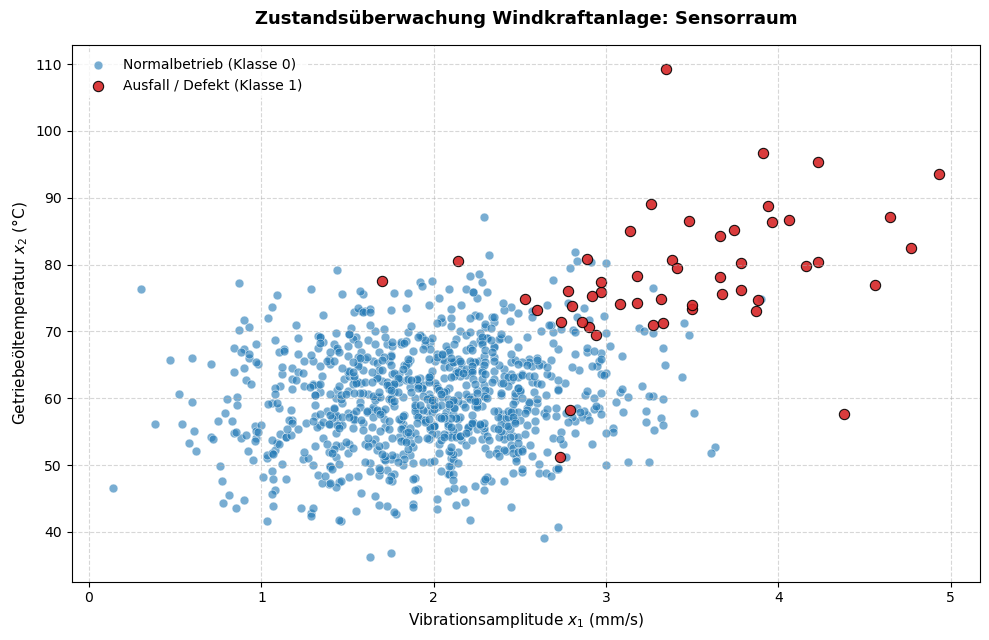

In [3]:
# =====================================================================
# Visualisierung der Features und der Ausfälle/Nichtausfälle
# =====================================================================

import matplotlib.pyplot as plt
import numpy as np

def plot_turbine_condition(X, y):
    """
    Visualisiert die Sensordaten im 2D-Merkmalraum.
    Klasse 0 (Normalbetrieb) = Blaue Kreise
    Klasse 1 (Ausfall) = Rote Kreise
    """
    plt.figure(figsize=(10, 6.5))
    
    # 1. Mehrheitsklasse: Normalbetrieb (Klasse 0)
    plt.scatter(
        X[y == 0, 0], X[y == 0, 1], 
        color='#1f77b4', marker='o', s=40, alpha=0.6, 
        edgecolors='w', linewidth=0.5, 
        label='Normalbetrieb (Klasse 0)'
    )
    
    # 2. Minderheitsklasse: Ausfall (Klasse 1)
    plt.scatter(
        X[y == 1, 0], X[y == 1, 1], 
        color='#d62728', marker='o', s=55, alpha=0.9, 
        edgecolors='black', linewidth=0.8, 
        label='Ausfall / Defekt (Klasse 1)'
    )
    
    # Achsenbeschriftung und Layout
    plt.title('Zustandsüberwachung Windkraftanlage: Sensorraum', fontsize=13, fontweight='bold', pad=15)
    plt.xlabel('Vibrationsamplitude $x_1$ (mm/s)', fontsize=11)
    plt.ylabel('Getriebeöltemperatur $x_2$ (°C)', fontsize=11)
    
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend(loc='upper left', frameon=True, facecolor='white', edgecolor='none')
    plt.tight_layout()
    plt.show()


# =====================================================================
# Visualisierung der Sensordaten im 2D-Merkmalraum
# =====================================================================

plot_turbine_condition(X_raw, y)

## Teil 1: Modellierung mit Scikit-Learn

Um dem starken Klassenungleichgewicht im Datensatz entgegenzuwirken, nutzen wir eine **gewichtete logistische Regression (Weighted Logistic Regression)**. Da wir bewusst im physikalischen Originalraum arbeiten und die Features vorab nicht standardisieren, müssen wir die Standard-L2-Regularisierung deaktivieren (`penalty=None`), um eine ungleichmäßige mathematische Verzerrung der Koeffizienten zu verhindern.

**Aufgabe 1 (Programmierung):**
Vervollständigen Sie den Code, um das Modell der logistischen Regression mit den korrekten Parametern zu instanziieren, sodass:

1. das Klassenungleichgewicht automatisch ausgeglichen wird (`class_weight`).
2. keine Regularisierung auf die Koeffizienten angewendet wird (`penalty`).

*Hinweis: Verwenden Sie `random_state=42`, um reproduzierbare Ergebnisse zu garantieren.*

In [15]:
from sklearn.linear_model import LogisticRegression

# 1. Modell instanziieren und fitten
# IHRE AUFGABE: Ergänzen Sie die Parameter für Gewichtung und Deaktivierung der Regularisierung

model = LogisticRegression(class_weight='balanced', penalty=None, random_state=42)
model.fit(X_raw, y)

# Koeffizienten ausgeben

print("Intercept (theta_0):", model.intercept_[0])
print("Koeffizienten (theta_1, theta_2):", model.coef_[0])

Intercept (theta_0): -22.695395850884395
Koeffizienten (theta_1, theta_2): [3.23370712 0.20655239]


### Teil 2: Interpretation der Koeffizieten & Entscheidungsgrenze

**Aufgabe 2a: (Theorie)**

Interpretieren Sie die gelernten Koeffizienten $\theta_1$ (für die Vibration) und $\theta_2$ (für die Temperatur) im Hinblick auf die quantitative Auswirkung einer zusätzlichen Einheit des jeweiligen Merkmals auf die **Odds (Chancen)** eines Getriebeausfalls.

In [18]:
# Ihre Interpretation:

print(
    "Eine Erhöhung der Vibration um 1 mm/s multipliziert die Odds eines Ausfalls "
    f"mit exp(theta_1) = {np.exp(theta_1):.2f}. ")
print(
    "Eine Erhöhung der Temperatur um 1 °C multipliziert die Odds eines Ausfalls "
    f"mit exp(theta_2) = {np.exp(theta_2):.2f}. ")
print(
    "Da beide Koeffizienten positiv sind, erhöhen beide Merkmale die Ausfall-Chancen. "
    "Die Vibration hat jedoch den deutlich stärkeren Einfluss.")


Eine Erhöhung der Vibration um 1 mm/s multipliziert die Odds eines Ausfalls mit exp(theta_1) = 25.37. 
Eine Erhöhung der Temperatur um 1 °C multipliziert die Odds eines Ausfalls mit exp(theta_2) = 1.23. 
Da beide Koeffizienten positiv sind, erhöhen beide Merkmale die Ausfall-Chancen. Die Vibration hat jedoch den deutlich stärkeren Einfluss.


**Aufgabe 2b (Programmierung):**

Vervollständigen Sie den Code, um die mathematische Entscheidungsgrenze (Trenngerade bei $z = 0$, sprich $p = 0.5$) in den Plot der Originaldaten einzufügen. 

*Hinweis: Die Trenngerade im Originalraum ist definiert durch $\theta_1 x_1 + \theta_2 x_2 + \theta_0 = 0$. Lösen Sie diese Gleichung nach $x_2$ (Temperatur) auf, um die y-Werte für den Plot zu berechnen.*

Steigung der Entscheidungsgrenze: -15.655626550889343
Y-Achsenabschnitt der Entscheidungsgrenze: 109.87718706785536


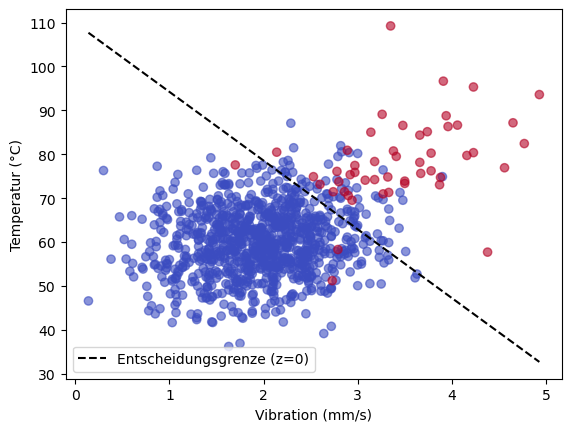

In [17]:
import numpy as np
import matplotlib.pyplot as plt

# Plot der Datenpunkte (vorgegeben)
plt.scatter(X_raw[:, 0], X_raw[:, 1], c=y, cmap='coolwarm', alpha=0.6)

# MUSTERLÖSUNG: Parameter extrahieren und nach x2 auflösen
theta_1, theta_2 = model.coef_[0]
theta_0 = model.intercept_[0]

x1_values = np.linspace(X_raw[:, 0].min(), X_raw[:, 0].max(), 100)
# Formel nach x2 auflösen (theta_1*x1 + theta_2*x2 + theta_0 = 0)
x2_values = -(theta_1 * x1_values + theta_0) / theta_2

print("Steigung der Entscheidungsgrenze:", -theta_1/theta_2)
print("Y-Achsenabschnitt der Entscheidungsgrenze:", -theta_0/theta_2)

# Plotten der Entscheidungsgrenze
plt.plot(x1_values, x2_values, label='Entscheidungsgrenze (z=0)', color='black', linestyle='--')
plt.xlabel('Vibration (mm/s)')
plt.ylabel('Temperatur (°C)')
plt.legend()
plt.show()

### Teil 3: Evaluation & Threshold-Tuning

Das trainierte Modell liefert kontinuierliche Ausfallwahrscheinlichkeiten $\hat{y} \in [0, 1]$. 
Um eine binäre Entscheidung (Normalbetrieb vs. Defekt) zu treffen, muss ein Klassifikations-Schwellenwert (Decision Threshold) festgelegt werden. 

Wir suchen nun den Schwellenwert im Bereich von $0.1$ bis $0.9$, der den **F1-Score** auf den Validierungsdaten maximiert.

**Aufgabe 3a (Programmierung):**
Vervollständigen Sie die `for`-Schleife im folgenden Code-Block, um die vorhergesagten Wahrscheinlichkeiten `y_probs` basierend auf dem aktuellen Threshold `c` in binäre Klassen (0 oder 1) zu transformieren.

In [7]:
from sklearn.metrics import f1_score

# Wahrscheinlichkeiten für die Validierungsdaten vorhersagen
y_probs = model.predict_proba(X_raw)[:, 1]

thresholds = np.arange(0.1, 0.95, 0.05)
best_threshold = 0.5
best_f1 = 0

for c in thresholds:
    # IHRE AUFGABE: Klassifizieren Sie die Datenpunkte basierend auf dem aktuellen Threshold c
    y_pred_class = (y_probs >= c).astype(int)
    
    score = f1_score(y, y_pred_class)
    
    if score > best_f1:
        best_f1 = score
        best_threshold = c

print(f"Optimaler Threshold: {best_threshold:.2f} mit F1-Score: {best_f1:.4f}")

Optimaler Threshold: 0.90 mit F1-Score: 0.7677


### Teil 3b: Kritische Analyse der Zielmetrik

Bei der Optimierung des Schwellenwerts im vorherigen Schritt fällt auf, dass der mathematisch optimale F1-Score bei einem sehr hohen Schwellenwert (z. B. $p = 0.90$) erreicht wird. Für die Überwachung der Windkraftanlage hat dies jedoch kritische Konsequenzen.

**Aufgabe 3b (Theorie):**

1. Begründen Sie kurz, weshalb der Standard-Schwellenwert von $p = 0.5$ für dieses konkrete Predictive-Maintenance-Modell ungeeignet ist, wenn das primäre Ziel die Vermeidung katastrophaler Schäden bei einer sehr geringen Schadenshäufigkeit (5 %) ist.

2. Welches fundamentale Problem im Kontext der Schadensfrüherkennung entsteht, wenn der Schwellenwert starr nach dem Maximum des Standard-F1-Scores (hier $p = 0.90$) gewählt wird? Wie lässt sich dieses Problem lösen?

In [ ]:
# Ihr Kommentar

# 1. Der Standardthreshold p=0.5 ist hier ungeeignet, da die Minderheitsklasse (Ausfälle) 
# nur 5% der Daten ausmacht. Dadurch liegt hier unbalanced data vor, was bei p=0.5
# dazu führt, dass die Minderheitenklasse unterrepräsentiert ist und bei der 
# Klassifikation vernachlässigt wird.

# 2. Durch die Anpassung des Thresholds auf einen Wert größer als 0.9 wird zwar der F1-Score verbessert,
# aber dies wird auf Kosten der Sensitivität (Recall) der Minderheitsklasse (Ausfälle) erkauft.
# Damit steigt die Anzahl der False Negatives, was in einem realen Szenario 
# zu einem Anstieg der unerkannten Ausfällen führt.

# Wie lässt sich dieses Problem lösen? 
# Verwendung einer anderen Metrik
# z. Bsp F_beta-Score mit beta=2, um die Sensitivität stärker zu gewichten.


### Teil 4: Visualisierung & Validierung der optimierten Entscheidungsgrenze

Durch das Absenken oder Anheben des Schwellenwerts verschiebt sich die Entscheidungsgrenze geometrisch im Raum. 

Mathematisch ist die neue Trenngerade durch die Bedingung definiert, bei der der Netzeingang $z$ exakt dem Logit des neuen Schwellenwerts $c_{\text{opt}}$ entspricht:

$$z = \ln\left(\frac{c_{\text{opt}}}{1 - c_{\text{opt}}}\right)$$

**Aufgabe 4a (Programmierung):**
Vervollständigen Sie den Code, um:
1. Die mathematische Gleichung der neuen Entscheidungsgrenze nach $x_2$ aufzulösen und diese als durchgehende Linie in den bestehenden Plot (neben der alten gestrichelten Linie für $p=0.5$) einzutragen.
2. Mittels `scikit-learn` die Konfusionsmatrizen (Confusion Matrices) für den Standardfall ($p=0.5$) und den optimierten Fall ($p=c_{\text{opt}}$) auf den Validierungsdaten auszugeben.

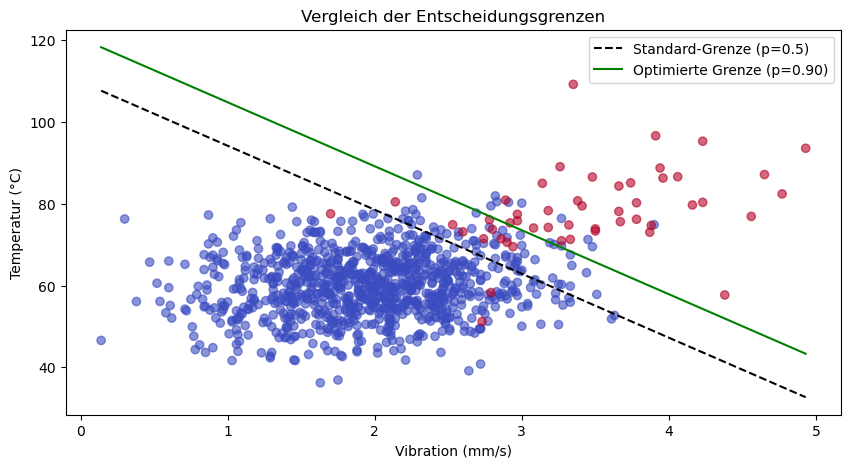

In [9]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt

# =====================================================================
# Teil 1: Neue Entscheidungsgrenze einzeichnen
# =====================================================================

plt.figure(figsize=(10, 5))

# Plot der Datenpunkte (vorgegeben)
plt.scatter(X_raw[:, 0], X_raw[:, 1], c=y, cmap='coolwarm', alpha=0.6)

# Parameter extrahieren
theta_1, theta_2 = model.coef_[0]
theta_0 = model.intercept_[0]
x1_values = np.linspace(X_raw[:, 0].min(), X_raw[:, 0].max(), 100)

# 1. Alte Entscheidungsgrenze bei p = 0.5 (vorgegeben)
x2_values_05 = -(theta_1 * x1_values + theta_0) / theta_2
plt.plot(x1_values, x2_values_05, label='Standard-Grenze (p=0.5)', color='black', linestyle='--')

# IHRE AUFGABE: Berechnen Sie das Logit für den optimalen Threshold und die neue Entscheidungsgrenze. Zeichnen Sie diese in den Plot ein.
c_opt = best_threshold
logit_t = np.log(c_opt / (1 - c_opt))

# Formel nach x2 auflösen: theta_1*x1 + theta_2*x2 + theta_0 = logit_t
x2_values_opt = (logit_t - theta_0 - theta_1 * x1_values) / theta_2


# Einzeichnen der neuen Entscheidungsgrenze
plt.plot(x1_values, x2_values_opt, label=f'Optimierte Grenze (p={c_opt:.2f})', color='green', linestyle='-')
plt.xlabel('Vibration (mm/s)')
plt.ylabel('Temperatur (°C)')
plt.legend()
plt.title('Vergleich der Entscheidungsgrenzen')
plt.show()



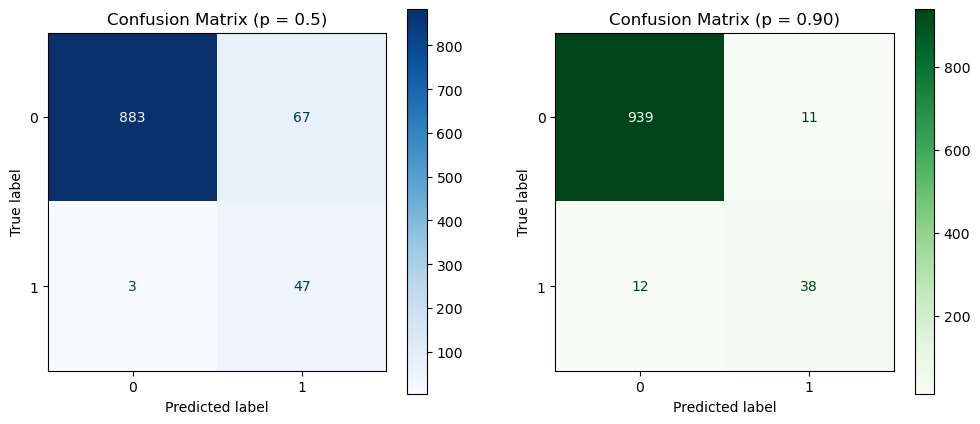

In [10]:
# =====================================================================
# Teil 2: Confusion Matrizen ausgeben
# =====================================================================

# Vorhersagen für beide Fälle generieren
y_pred_05 = (y_probs >= 0.5).astype(int)
y_pred_opt = (y_probs >= c_opt).astype(int)

# Berechnen Sie die Confusion Matrices
cm_05 = confusion_matrix(y, y_pred_05)
cm_opt = confusion_matrix(y, y_pred_opt)

# Ausgabe (entweder als Print oder hübsch mit ConfusionMatrixDisplay)
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay(cm_05).plot(ax=ax[0], cmap='Blues')
ax[0].set_title('Confusion Matrix (p = 0.5)')

ConfusionMatrixDisplay(cm_opt).plot(ax=ax[1], cmap='Greens')
ax[1].set_title(f'Confusion Matrix (p = {c_opt:.2f})')
plt.show()

Text(0.5, 1.0, 'F1-Score vs. Threshold')

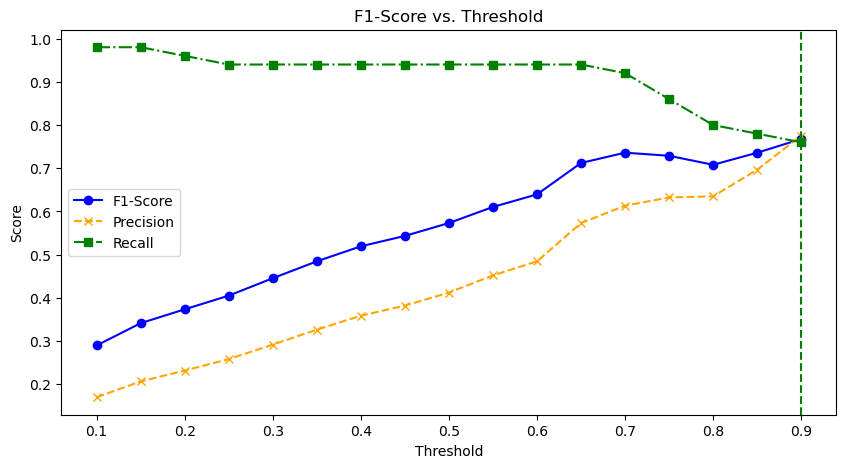

In [11]:
# Plotten Sie die F1-Scores, sowie Precision-Recall-Kurven für verschiedene Thresholds, um die Optimierung zu visualisieren

from sklearn.metrics import recall_score
from sklearn.metrics import precision_score

f1_scores = [f1_score(y, (y_probs >= c).astype(int)) for c in thresholds]

# Precision-Recall-Kurven
precision_scores = [precision_score(y, (y_probs >= c).astype(int)) for c in thresholds]
recall_scores = [recall_score(y, (y_probs >= c).astype(int)) for c in thresholds]

plt.figure(figsize=(10, 5))
plt.plot(thresholds, f1_scores, marker='o', linestyle='-', color='blue')
plt.plot(thresholds, precision_scores, marker='x', linestyle='--', color='orange')
plt.plot(thresholds, recall_scores, marker='s', linestyle='-.', color='green')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.legend(['F1-Score', 'Precision', 'Recall'])

plt.axvline(x=c_opt, color='green', linestyle='--', label=f'Optimaler Threshold (p={c_opt:.2f})')
plt.title('F1-Score vs. Threshold')
